This notebook compares the dist change of different embedding methods, namely `Gaussian Embedding(GE)`, `scVI/VAE`, `Diffusion map(DF)`, `UMAP`, `t-SNE`. We compute the `Coefficient of Variation(CV)` of dist_embedding/dist_original for each edges in KNN constructed in the original space. **Small CV implicates low variation of the dist ratio, thus methods with small CV preserves the local metric better.**

In [64]:
import os
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scvi
import scvelo as scv
from scipy.sparse import csr_matrix
from utils import kde_lowess

In [102]:
data_path='data/'
data_name = 'A549_emt_bin_ppt'
adata=sc.read('data/'+data_name+'.h5ad', cache=True)

if data_name == 'endocrinogenesis_day15.5':
    sc.pp.filter_genes(adata, min_counts=3)
    sc.pp.filter_cells(adata, min_counts=20)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    )
    adata = adata[:, adata.var.highly_variable]
    
    adata.layers['Ms'] = adata.layers['spliced']
    adata.layers['Mu'] = adata.layers['unspliced']  
 
adata

AnnData object with n_obs × n_vars = 2961 × 437
    obs: 'Clusters', '_X', '_Y', 'batch', 'sample', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'palantir_pseudotime', 'palantir_entropy'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'DM_EigenValues', 'neighbors', 'palantir_waypoints', 'pca', 'sample_colors', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'palantir_fate_probabilities', 'velocity_pca'
    varm: 'PCs'
    layers: 'MAGIC_imputed_data', 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

## **Defaults**

In [103]:
# Parameters: k_nei for KNN, L for latent dimension, seed for random seed
[k_nei, K, L, seed] = [30, 2, 10, 0]

random.seed(seed)
result_path = 'cvresults/'+data_name+str([k_nei, L, seed])+'/'
figure_path = result_path
cmap = plt.colormaps['Spectral_r']

folder = os.path.exists(result_path)
if not folder:                   
    os.makedirs(result_path)  

## **PCA, UMAP, t-SNE**

In [104]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=k_nei)
sc.tl.umap(adata)
sc.tl.tsne(adata)

In [105]:
gene_arr=adata.var.index.values
X_pca=adata.obsm['X_pca']
X_umap=adata.obsm['X_umap']
X_tsne=adata.obsm['X_tsne']
Xs=adata.layers['Ms']

## **DF**

In [106]:
# Use alpha=1 kernel

eps = 30 # tunning hyperparameter!!! Gaussian width
alpha = 1

X = adata.X.toarray()
XXT = X@X.T # i,j-element is the inner prod of i,j rows of X
X2 = np.array([np.sum(X**2,axis=1),])

D2 = X2 + X2.T - 2*XXT # i,j-element is the square Euclidean distance of the i,j rows of X 
D2 = D2*(D2 >= 0) # to avoid numerical error
D = np.sqrt(D2) # pairwise Euclidean distances

kernel = np.exp(-D2/eps) # Graph-Laplacian where alpha = 0

q = np.array([np.sum(kernel,axis=1),])
q = q**alpha
K_alpha = kernel/(q.T@q)

p = np.zeros_like(K_alpha)
d_alpha = np.sum(K_alpha,axis=1)
for i in range(len(d_alpha)):
    p[i,:] = K_alpha[i,:]/d_alpha[i]

# p is the Markov matrix

# compute the eigen decomposition of p
eigs, eigvecs = np.linalg.eig(p)

# use 1 step transition is ok
X_diff = eigvecs[:,1:16]@np.diag(eigs[1:16])

## **scVI**

In [107]:
VAE_path = 'results/'+data_name+str([k_nei, L, seed])+'/'
scvi.model.SCVI.setup_anndata(adata)
VAE = scvi.model.SCVI.load(VAE_path+'model', adata=adata)
X_scvi = VAE.get_latent_representation()

INFO     File results/A549_emt_bin_ppt[30, 10, 0]/model/model.pt already downloaded                                


## **GE**
We previously trained a GE encoder with parameters `[k_nei, K, L] = [30, 2, 10]`, and we just load it here instead of training again

In [108]:
GE_path = 'GEresults/'+data_name+str([k_nei, K, L])+'/'
encoder = torch.load(GE_path+'encoder.pt')

In [109]:
mu, sigma = encoder(torch.tensor(Xs))
X_mu = mu.detach().numpy()
X_sigma = sigma.detach().numpy()

## **Calcualte distance pair**

In [110]:
def Fisher_dist(mu1,sigma1,mu2,sigma2):
    dim=len(mu1)
    dF2=0
    for i in range(dim):
        a=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)+\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        b=np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]+sigma2[i])**2)-\
          np.sqrt(((mu1[i]-mu2[i])/np.sqrt(2))**2+(sigma1[i]-sigma2[i])**2)
        
        dF2+=2*(np.log(a/b))**2
    dF=np.sqrt(dF2)
    return dF

In [111]:
row = np.array([np.ones((k_nei,))*i for i in range(adata.shape[0])]).flatten()
col = (adata.obsp['distances']+csr_matrix(np.eye(adata.obsp['distances'].shape[0]))).indices
w_val = np.array([np.linalg.norm(X_pca[int(i),:]-X_pca[int(j),:]) for i,j in zip(row,col)])
adj_val = np.ones(col.shape)
A = csr_matrix((adj_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))
W_mat = csr_matrix((w_val, (row, col)), shape=(adata.shape[0], adata.shape[0]))

In [112]:
dist_ratios_Ge=[]
dist_ratios_umap = []
dist_ratios_tsne = []
dist_ratios_df = []
dist_ratios_vae = []
Lvae = X_scvi.shape[1]//2

for inds in np.split(A.indices, A.indptr)[1:-1]:

    dist_r_Ge = []
    dist_r_umap = []
    dist_r_tsne = []
    dist_r_df = []
    dist_r_vae = []
    self_ind=inds[0]
    for nei_k in range(1,len(inds)):
        
        dEu=np.linalg.norm(Xs[self_ind,:]-Xs[inds[nei_k],:])
        dumap=np.linalg.norm(X_umap[self_ind,:]-X_umap[inds[nei_k],:])
        dtsne=np.linalg.norm(X_tsne[self_ind,:]-X_tsne[inds[nei_k],:])
        ddf=np.linalg.norm(X_diff[self_ind,:]-X_diff[inds[nei_k],:])
        dGe=Fisher_dist(X_mu[self_ind,:],X_sigma[self_ind,:],\
                        X_mu[inds[nei_k],:],X_sigma[inds[nei_k],:])
        dvae=Fisher_dist(X_scvi[self_ind,:Lvae],np.exp(X_scvi[self_ind,Lvae:]/2),\
                        X_scvi[inds[nei_k],:Lvae],np.exp(X_scvi[inds[nei_k],Lvae:]/2))
        
        
        dist_r_Ge.append(dEu/dGe)
        dist_r_umap.append(dEu/dumap)
        dist_r_tsne.append(dEu/dtsne)
        dist_r_df.append(dEu/ddf)
        dist_r_vae.append(dEu/dvae)


        
#     print(np.std(dist_r)/np.mean(dist_r))
    
    dist_ratios_Ge.append(np.std(dist_r_Ge)/np.mean(dist_r_Ge))
    dist_ratios_umap.append(np.std(dist_r_umap)/np.mean(dist_r_umap))
    dist_ratios_tsne.append(np.std(dist_r_tsne)/np.mean(dist_r_tsne))
    dist_ratios_df.append(np.std(dist_r_df)/np.mean(dist_r_df))
    dist_ratios_vae.append(np.std(dist_r_vae)/np.mean(dist_r_vae))

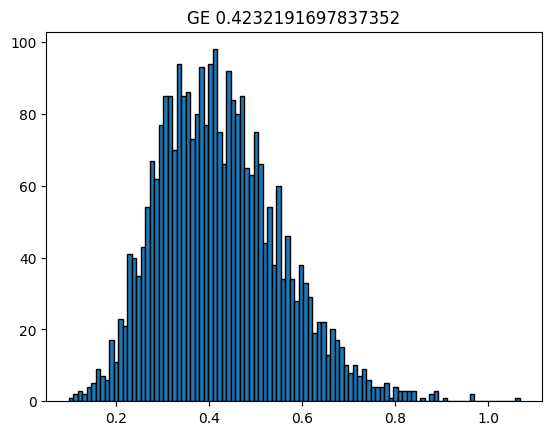

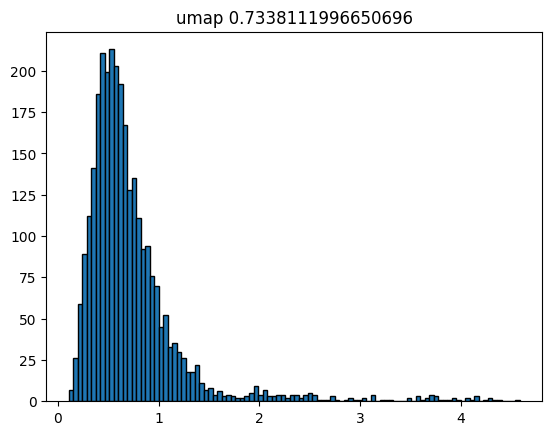

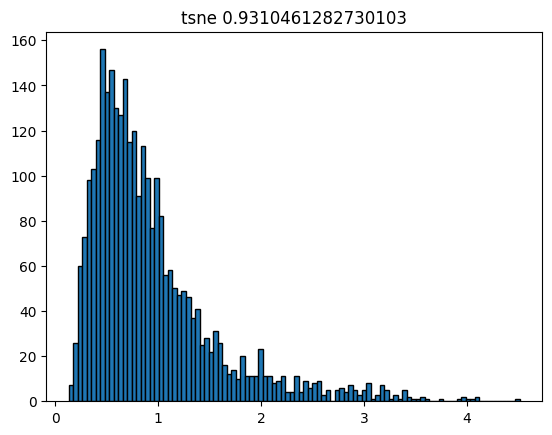

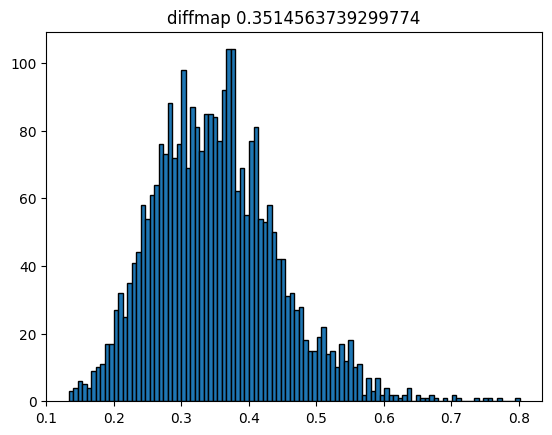

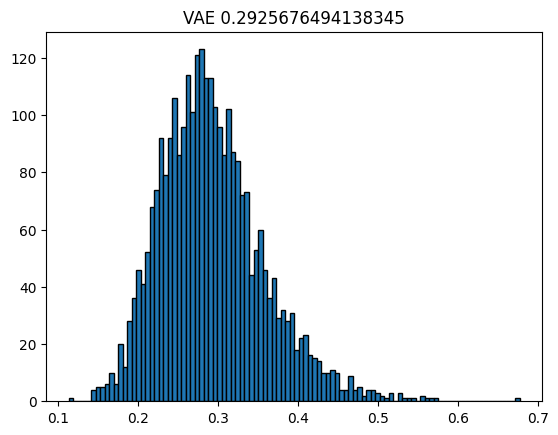

In [113]:
plt.hist(np.array(dist_ratios_Ge),bins=100,edgecolor='black')
plt.title(f'GE {np.mean(dist_ratios_Ge)}')
plt.savefig(result_path+'GE')
plt.show()

plt.hist(np.array(dist_ratios_umap),bins=100,edgecolor='black')
plt.title(f'umap {np.mean(dist_ratios_umap)}')
plt.savefig(result_path+'UMAP')
plt.show()

plt.hist(np.array(dist_ratios_tsne),bins=100,edgecolor='black')
plt.title(f'tsne {np.mean(dist_ratios_tsne)}')
plt.savefig(result_path+'tSNE')
plt.show()

plt.hist(np.array(dist_ratios_df),bins=100,edgecolor='black')
plt.title(f'diffmap {np.mean(dist_ratios_df)}')
plt.savefig(result_path+'DF')
plt.show()

plt.hist(np.array(dist_ratios_vae),bins=100,edgecolor='black')
plt.title(f'VAE {np.mean(dist_ratios_vae)}')
plt.savefig(result_path+'VAE')
plt.show()